In [1]:
#install and Import PySwarms
!pip install pyswarms

In [6]:
import pyswarms as ps
import numpy as np
from pyswarms.utils.functions import single_obj as fx
import matplotlib.pyplot as plt

In [10]:
%%time
#Three steps to optimization:

# 1) To configure the swarm as a dict, set-up hyperparameters.
options = {'c1': 0.5, 'c2': 0.3, 'w':0.9}

# Call instance of PSO: implement the global-best optimizer using PySwarms’s functional API
# 2) Pass the dictionary along with the relevant inputs to create an instance of the optimizer.

optimizer = ps.single.GlobalBestPSO(n_particles=10, dimensions=2, options=options)

# Perform optimization
# 3) Invoke the optimize() method, and tell it to save the best cost and position in a variable.
cost, pos = optimizer.optimize(fx.sphere, iters=1000)

2023-04-23 21:38:02,150 - pyswarms.single.global_best - INFO - Optimize for 1000 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|████████████████|1000/1000, best_cost=3.73e-43
2023-04-23 21:38:02,779 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 3.727123960579536e-43, best pos: [-3.44030411e-22  5.04336666e-22]


CPU times: user 440 ms, sys: 99 ms, total: 539 ms
Wall time: 638 ms


In [11]:
# Import modules
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image

# Import PySwarms
import pyswarms as ps
from pyswarms.utils.functions import single_obj as fx
from pyswarms.utils.plotters import (plot_cost_history, plot_contour, plot_surface)

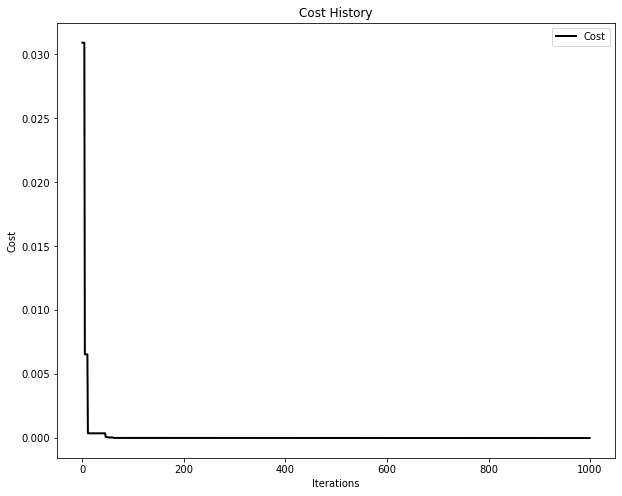

In [12]:
plot_cost_history(cost_history=optimizer.cost_history)
plt.show()

In [13]:
from pyswarms.utils.plotters.formatters import Mesher

In [14]:
# Initialize mesher with sphere function
m = Mesher(func=fx.sphere)

In [15]:
%%capture
# Make animation
animation = plot_contour(pos_history=optimizer.pos_history,
                         mesher=m,
                         mark=(0,0))


In [16]:
# Enables us to view it in a Jupyter notebook
animation.save('plot0.gif', writer='imagemagick', fps=5)
Image(url='plot0.gif')
# if fails with MovieWriterRegistry Error: install imagemagick (apt install)

2023-04-23 21:38:43,949 - matplotlib.animation - WARNING - MovieWriter imagemagick unavailable; using Pillow instead.
2023-04-23 21:38:43,950 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.PillowWriter'>


In [17]:
# Obtain a position-fitness matrix using the Mesher.compute_history_3d()
# method. It requires a cost history obtainable from the optimizer class
pos_history_3d = m.compute_history_3d(optimizer.pos_history)

In [18]:
# Make a designer and set the x,y,z limits to (-1,1), (-1,1) and (-0.1,1) respectively
from pyswarms.utils.plotters.formatters import Designer
d = Designer(limits=[(-1,1), (-1,1), (-0.1,1)], label=['x-axis', 'y-axis', 'z-axis'])

In [19]:
%%capture
# Make animation
animation3d = plot_surface(pos_history=pos_history_3d, # Use the cost_history we computed
                           mesher=m, designer=d,       # Customizations
                           mark=(0,0,0))               # Mark minima

In [20]:
animation3d.save('plot1.gif', writer='imagemagick', fps=10)
Image(url='plot1.gif')

2023-04-23 21:39:46,336 - matplotlib.animation - WARNING - MovieWriter imagemagick unavailable; using Pillow instead.
2023-04-23 21:39:46,338 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.PillowWriter'>
